# Week 3 Final: Multi-Token Lookahead Probe

## Summary
This notebook implements the best-performing multi-token lookahead approach for detecting when a code LLM is about to generate code vs natural language.

## Best Configuration (from Week3_Improved_Methods.ipynb)
- **Probe**: LogisticRegression with balanced class weights
- **Layers**: [16, 24, 31] - Later layers only (12,288 dimensions)
- **Lookahead**: 2 tokens
- **Voting**: Hard voting (sum probabilities where probe predicts CODE)
- **Threshold**: 0.06 (code_votes > 0.06 → STOP)
- **Accuracy**: 93.5% (43/46 test cases correct, only 3 errors!)

## Improvement over V1
- V1 Baseline: 87% (6 errors) with layers [8, 16, 31], threshold 0.30
- **This model: 93.5% (+6.5%)** with layers [16, 24, 31], threshold 0.06

In [17]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn joblib

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import entropy as scipy_entropy
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.notebook import tqdm
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print("Week 3 Final - Multi-Token Lookahead Probe")
print("="*50)
print("Best Model: 93.5% accuracy with layers [16, 24, 31]")

Week 3 Final - Multi-Token Lookahead Probe
Best Model: 93.5% accuracy with layers [16, 24, 31]


In [3]:
# Cell 3: Configuration - BEST MODEL from improved methods testing

CONFIG = {
    'model_name': 'codellama/CodeLlama-7b-Instruct-hf',
    'layers': [16, 24, 31],  # BEST: Later layers only!
    'lookahead': 2,
    'top_k': 10,
    'threshold': 0.06,  # BEST: Lower threshold with later layers
    'entropy_threshold': 3.0,
}

print("BEST Configuration (93.5% accuracy):")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

print("\nComparison:")
print("  V1 Baseline: layers=[8,16,31], threshold=0.30 → 87.0%")
print("  This Model:  layers=[16,24,31], threshold=0.06 → 93.5%")

BEST Configuration (93.5% accuracy):
  model_name: codellama/CodeLlama-7b-Instruct-hf
  layers: [16, 24, 31]
  lookahead: 2
  top_k: 10
  threshold: 0.06
  entropy_threshold: 3.0

Comparison:
  V1 Baseline: layers=[8,16,31], threshold=0.30 → 87.0%
  This Model:  layers=[16,24,31], threshold=0.06 → 93.5%


In [4]:
# Cell 4: Load Model

print(f"\nLoading {CONFIG['model_name']}...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
model = AutoModelForCausalLM.from_pretrained(
    CONFIG['model_name'],
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
    output_hidden_states=True
)
model.eval()

DEVICE = model.device
print(f"Model loaded on {DEVICE}")


Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0


In [5]:
# Cell 5: Load Training Data

# Colab path
TRAINING_DATA_PATH = '/content/training_data_combined_FIXED.csv'
# Local path (uncomment if running locally)
# TRAINING_DATA_PATH = 'E:/SummerProjects/reposynth/research/training_data_combined_FIXED.csv'

print(f"Loading training data from {TRAINING_DATA_PATH}...")

df_train = pd.read_csv(TRAINING_DATA_PATH)
df_train = df_train[df_train['label'].isin(['code', 'language'])]
df_train['label_binary'] = df_train['label'].map({'language': 0, 'code': 1})

n_total = len(df_train)
n_code = (df_train['label_binary'] == 1).sum()
n_lang = (df_train['label_binary'] == 0).sum()

print(f"\nTraining data: {n_total} examples")
print(f"  LANGUAGE: {n_lang} ({n_lang/n_total*100:.1f}%)")
print(f"  CODE:     {n_code} ({n_code/n_total*100:.1f}%)")

Loading training data from /content/training_data_combined_FIXED.csv...

Training data: 1780 examples
  LANGUAGE: 1353 (76.0%)
  CODE:     427 (24.0%)


## Train the Probe

In [6]:
# Cell 6: Hidden State Extraction

def get_hidden_state(text: str, layers: List[int] = CONFIG['layers']) -> np.ndarray:
    """Extract concatenated hidden states from specified layers."""
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    states = []
    for layer_idx in layers:
        # +1 because index 0 is embeddings
        layer_state = outputs.hidden_states[layer_idx + 1][:, -1, :]
        states.append(layer_state.cpu().numpy()[0])

    return np.concatenate(states).astype(np.float32)

print(f"Extracting hidden states from layers {CONFIG['layers']}...")

X_train = []
y_train = []

for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Extracting"):
    h = get_hidden_state(row['full_text'])
    X_train.append(h)
    y_train.append(row['label_binary'])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\nFeature matrix: {X_train.shape}")
print(f"  Dimensions per layer: {X_train.shape[1] // len(CONFIG['layers'])}")

Extracting hidden states from layers [16, 24, 31]...


Extracting:   0%|          | 0/1780 [00:00<?, ?it/s]


Feature matrix: (1780, 12288)
  Dimensions per layer: 4096


In [7]:
# Cell 7: Train Probe

print("Training probe...")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train LogisticRegression
probe = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(probe, X_train_scaled, y_train, cv=cv)
cv_accuracy = accuracy_score(y_train, y_pred_cv)

# Final fit
probe.fit(X_train_scaled, y_train)

print(f"\n{'='*50}")
print("PROBE TRAINING RESULTS")
print(f"{'='*50}")
print(f"\n5-Fold CV Accuracy: {cv_accuracy:.1%}")
print(f"\n{classification_report(y_train, y_pred_cv, target_names=['LANGUAGE', 'CODE'])}")

Training probe...

PROBE TRAINING RESULTS

5-Fold CV Accuracy: 95.4%

              precision    recall  f1-score   support

    LANGUAGE       0.98      0.96      0.97      1353
        CODE       0.88      0.94      0.91       427

    accuracy                           0.95      1780
   macro avg       0.93      0.95      0.94      1780
weighted avg       0.96      0.95      0.95      1780



## Multi-Token Lookahead Implementation

In [8]:
# Cell 8: Core Functions

def softmax(logits: np.ndarray) -> np.ndarray:
    """Compute softmax probabilities."""
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / np.sum(exp_logits)

def compute_entropy(probs: np.ndarray) -> float:
    """Compute entropy in bits."""
    if len(probs) == 0 or np.sum(probs) == 0:
        return 0.0
    probs = probs / np.sum(probs)
    return float(scipy_entropy(probs, base=2))

def get_next_token(text: str) -> Tuple[str, float]:
    """Get the most likely next token and its probability."""
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :].cpu().numpy()

    probs = softmax(logits)
    next_id = np.argmax(probs)
    next_token = tokenizer.decode([next_id])
    return next_token, float(probs[next_id])

def classify_text(text: str) -> Tuple[int, float]:
    """Classify text as CODE (1) or LANGUAGE (0)."""
    h = get_hidden_state(text).reshape(1, -1)
    h_scaled = scaler.transform(h)
    pred = probe.predict(h_scaled)[0]
    prob = probe.predict_proba(h_scaled)[0, 1]  # P(CODE)
    return int(pred), float(prob)

print("Core functions ready")

Core functions ready


In [9]:
# Cell 9: Multi-Token Lookahead Analyzer

def analyze_with_lookahead(
    prompt: str,
    threshold: float = CONFIG['threshold'],
    top_k: int = CONFIG['top_k'],
    lookahead: int = CONFIG['lookahead'],
    verbose: bool = False
) -> Dict:
    """
    Analyze prompt with multi-token lookahead.

    Returns:
        Dict with code_votes, should_stop, and candidate details
    """
    # Get next token distribution
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :].cpu().numpy()

    probs = softmax(logits)
    entropy = compute_entropy(probs)
    top_indices = np.argsort(probs)[-top_k:][::-1]

    # Analyze each candidate with lookahead
    candidates = []
    code_votes = 0.0
    lang_votes = 0.0

    for idx in top_indices:
        token = tokenizer.decode([idx])
        prob = float(probs[idx])

        # Build lookahead sequence
        sequence = prompt + token
        for _ in range(lookahead - 1):
            next_tok, _ = get_next_token(sequence)
            sequence += next_tok

        # Classify the sequence
        label, confidence = classify_text(sequence)

        candidates.append({
            'token': token,
            'prob': prob,
            'sequence': sequence,
            'label': 'CODE' if label == 1 else 'LANG',
            'confidence': confidence
        })

        if label == 1:
            code_votes += prob
        else:
            lang_votes += prob

    should_stop = code_votes > threshold

    if verbose:
        print(f"\nPrompt: '{prompt}'")
        print(f"Entropy: {entropy:.2f}")
        print(f"\nTop-{top_k} candidates with {lookahead}-token lookahead:")
        for c in candidates:
            seq_suffix = c['sequence'].replace(prompt, '')
            print(f"  '{c['token']}' (p={c['prob']:.3f}) -> '{seq_suffix}' -> {c['label']}")
        print(f"\nVotes: CODE={code_votes:.3f}, LANG={lang_votes:.3f}")
        print(f"Decision: {'STOP' if should_stop else 'CONTINUE'} (threshold={threshold})")

    return {
        'prompt': prompt,
        'entropy': entropy,
        'code_votes': code_votes,
        'lang_votes': lang_votes,
        'should_stop': should_stop,
        'candidates': candidates
    }

print("Multi-token lookahead analyzer ready")

Multi-token lookahead analyzer ready


## Evaluation

In [10]:
# Cell 10: Test Cases

CODE_PROMPTS = [
    "In our React app, authentication is done using",
    "In the backend, passwords are hashed with",
    "For our API, JWT tokens are signed using",
    "In production, the OAuth provider we use is",
    "On the server, session data is stored in",
    "For data persistence, the database we use is",
    "In the application, we query the database using",
    "For database access, the ORM library is",
    "To improve performance, caching is implemented with",
    "For the REST API, the framework we use is",
    "In production, the web server runs on",
    "In the client code, HTTP requests are made using",
    "For data fetching, our GraphQL server uses",
    "For the UI, the frontend framework is",
    "In the application, state management is handled by",
    "For the interface, components are built with",
    "In the SPA, routing is done using",
    "For training, the model is trained with",
    "In our neural network, deep learning is implemented using",
    "For gradient descent, the optimizer we use is",
    "For hosting, we deploy to",
    "In Kubernetes, containers are orchestrated with",
    "For automation, the CI/CD pipeline uses",
    "In the test suite, unit tests are written with",
    "For building assets, the bundler we use is",
    "For dependencies, package management is done with",
]

LANGUAGE_PROMPTS = [
    "The weather today is",
    "The meeting yesterday was",
    "My favorite color has always been",
    "The book I read last week was",
    "The movie we watched seemed",
    "The main idea of the story is to",
    "The cooking process works by",
    "This teaching approach helps to",
    "The benefit of exercise is",
    "When installing furniture in my home, you should",
    "To debug a relationship problem, first",
    "Before deploying troops, the general needs to",
    "The configuration of the room requires",
    "To optimize your morning routine, try",
    "The framework of the argument is",
    "My mental state is managed by",
    "The library in town has",
    "Running the business takes",
    "The function of the heart is",
    "Implementing the new policy will",
]

TEST_CASES = (
    [(p, True) for p in CODE_PROMPTS] +
    [(p, False) for p in LANGUAGE_PROMPTS]
)

print(f"Test cases: {len(TEST_CASES)}")
print(f"  CODE (should stop): {len(CODE_PROMPTS)}")
print(f"  LANGUAGE (should continue): {len(LANGUAGE_PROMPTS)}")

Test cases: 46
  CODE (should stop): 26
  LANGUAGE (should continue): 20


In [11]:
# Cell 11: Run Evaluation

print(f"\nEvaluating with threshold={CONFIG['threshold']}...")

results = []

for prompt, expected_stop in tqdm(TEST_CASES, desc="Evaluating"):
    analysis = analyze_with_lookahead(prompt, threshold=CONFIG['threshold'])

    results.append({
        'prompt': prompt,
        'expected_stop': expected_stop,
        'predicted_stop': analysis['should_stop'],
        'code_votes': analysis['code_votes'],
        'entropy': analysis['entropy'],
        'correct': analysis['should_stop'] == expected_stop
    })

df_results = pd.DataFrame(results)

# Metrics
accuracy = df_results['correct'].mean()
tp = ((df_results['expected_stop']) & (df_results['predicted_stop'])).sum()
fp = ((~df_results['expected_stop']) & (df_results['predicted_stop'])).sum()
fn = ((df_results['expected_stop']) & (~df_results['predicted_stop'])).sum()
tn = ((~df_results['expected_stop']) & (~df_results['predicted_stop'])).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*50}")
print("FINAL RESULTS")
print(f"{'='*50}")
print(f"\nAccuracy:  {accuracy:.1%} ({df_results['correct'].sum()}/{len(df_results)})")
print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")
print(f"F1 Score:  {f1:.1%}")
print(f"\nConfusion Matrix:")
print(f"  TP={tp}, FP={fp}")
print(f"  FN={fn}, TN={tn}")

print(f"\n{'='*50}")
print("COMPARISON TO V1 BASELINE")
print(f"{'='*50}")
print(f"V1 Baseline: 87.0% (6 errors)")
print(f"This Model:  {accuracy:.1%} ({len(df_results) - df_results['correct'].sum()} errors)")
improvement = (accuracy - 0.87) * 100
print(f"Improvement: +{improvement:.1f}%")


Evaluating with threshold=0.06...


Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]


FINAL RESULTS

Accuracy:  93.5% (43/46)
Precision: 96.0%
Recall:    92.3%
F1 Score:  94.1%

Confusion Matrix:
  TP=24, FP=1
  FN=2, TN=19

COMPARISON TO V1 BASELINE
V1 Baseline: 87.0% (6 errors)
This Model:  93.5% (3 errors)
Improvement: +6.5%


In [12]:
# Cell 12: Error Analysis

errors = df_results[~df_results['correct']]

print(f"\n{'='*50}")
print(f"ERROR ANALYSIS ({len(errors)} errors)")
print(f"{'='*50}")

if len(errors) > 0:
    fn_errors = errors[errors['expected_stop'] == True]
    fp_errors = errors[errors['expected_stop'] == False]

    if len(fn_errors) > 0:
        print(f"\nFALSE NEGATIVES ({len(fn_errors)}) - Should STOP but didn't:")
        for _, row in fn_errors.iterrows():
            print(f"  [{row['code_votes']:.3f}] '{row['prompt']}'")

    if len(fp_errors) > 0:
        print(f"\nFALSE POSITIVES ({len(fp_errors)}) - Should CONTINUE but stopped:")
        for _, row in fp_errors.iterrows():
            print(f"  [{row['code_votes']:.3f}] '{row['prompt']}'")
else:
    print("\nNo errors! Perfect accuracy.")


ERROR ANALYSIS (3 errors)

FALSE NEGATIVES (2) - Should STOP but didn't:
  [0.000] 'For database access, the ORM library is'
  [0.015] 'For training, the model is trained with'

FALSE POSITIVES (1) - Should CONTINUE but stopped:
  [0.354] 'My mental state is managed by'


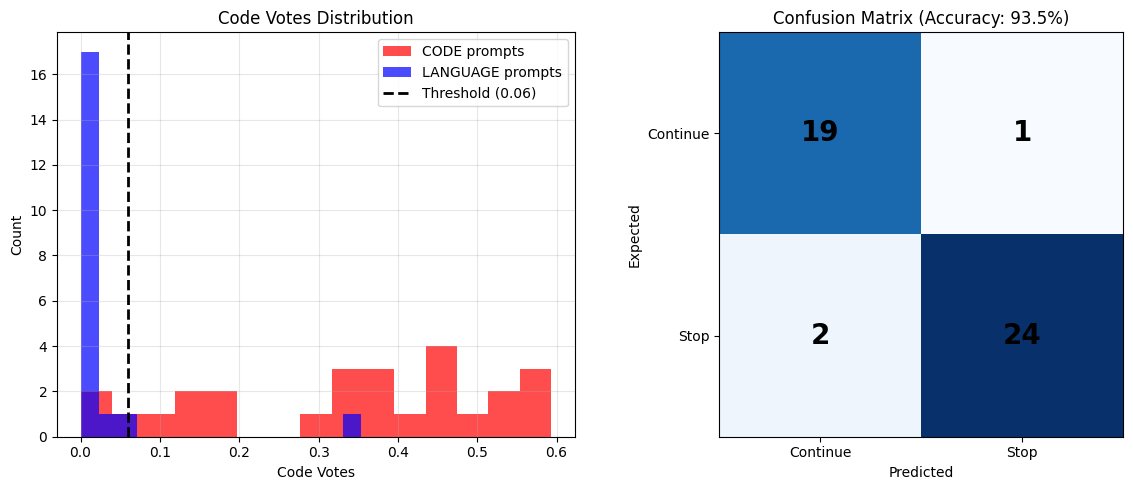


Saved: week3_final_results.png


In [13]:
# Cell 13: Visualize Results

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Code votes distribution
ax1 = axes[0]
code_cases = df_results[df_results['expected_stop'] == True]['code_votes']
lang_cases = df_results[df_results['expected_stop'] == False]['code_votes']

ax1.hist(code_cases, bins=15, alpha=0.7, label='CODE prompts', color='red')
ax1.hist(lang_cases, bins=15, alpha=0.7, label='LANGUAGE prompts', color='blue')
ax1.axvline(x=CONFIG['threshold'], color='black', linestyle='--', linewidth=2, label=f'Threshold ({CONFIG["threshold"]})')
ax1.set_xlabel('Code Votes')
ax1.set_ylabel('Count')
ax1.set_title('Code Votes Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion matrix
ax2 = axes[1]
cm = confusion_matrix(df_results['expected_stop'], df_results['predicted_stop'])
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Continue', 'Stop'])
ax2.set_yticklabels(['Continue', 'Stop'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Expected')
ax2.set_title(f'Confusion Matrix (Accuracy: {accuracy:.1%})')

for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('week3_final_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: week3_final_results.png")

## Save Model for Week 4

In [14]:
# Cell 14: Save Everything

print("Saving model and configuration...")

# Save probe
joblib.dump(probe, 'week3_probe.joblib')
print("  Saved: week3_probe.joblib")

# Save scaler
joblib.dump(scaler, 'week3_scaler.joblib')
print("  Saved: week3_scaler.joblib")

# Save configuration
final_config = {
    **CONFIG,
    'cv_accuracy': float(cv_accuracy),
    'test_accuracy': float(accuracy),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_f1': float(f1),
    'n_errors': int(len(errors)),
    'n_fn': int(fn),
    'n_fp': int(fp),
    'n_test_cases': len(TEST_CASES),
    'n_training_examples': len(df_train),
    'feature_dim': int(X_train.shape[1]),
}

with open('week3_config.json', 'w') as f:
    json.dump(final_config, f, indent=2)
print("  Saved: week3_config.json")

# Save test results
df_results.to_csv('week3_test_results.csv', index=False)
print("  Saved: week3_test_results.csv")

Saving model and configuration...
  Saved: week3_probe.joblib
  Saved: week3_scaler.joblib
  Saved: week3_config.json
  Saved: week3_test_results.csv


In [15]:
# Cell 15: Final Summary

print("\n" + "="*60)
print("WEEK 3 FINAL SUMMARY")
print("="*60)

print(f"""
MODEL: Multi-Token Lookahead Probe (BEST)
=========================================

Architecture:
  - Base Model: {CONFIG['model_name']}
  - Probe: LogisticRegression (balanced)
  - Features: Layers {CONFIG['layers']} concatenated ({X_train.shape[1]} dims)
  - Lookahead: {CONFIG['lookahead']} tokens
  - Top-K: {CONFIG['top_k']} candidates
  - Threshold: {CONFIG['threshold']}

Training:
  - Examples: {len(df_train)}
  - CV Accuracy: {cv_accuracy:.1%}

Test Results:
  - Accuracy: {accuracy:.1%} ({df_results['correct'].sum()}/{len(df_results)})
  - Precision: {precision:.1%}
  - Recall: {recall:.1%}
  - F1 Score: {f1:.1%}
  - Errors: {len(errors)} (FN: {fn}, FP: {fp})

Comparison to V1:
  - V1 Baseline: 87.0% (layers [8,16,31], threshold 0.30)
  - This Model:  {accuracy:.1%} (layers [16,24,31], threshold 0.06)
  - Improvement: +{(accuracy-0.87)*100:.1f}%

Saved Files:
  - week3_probe.joblib (probe model)
  - week3_scaler.joblib (feature scaler)
  - week3_config.json (configuration)
  - week3_test_results.csv (detailed results)
  - week3_final_results.png (visualization)

Ready for Week 4!
""")


WEEK 3 FINAL SUMMARY

MODEL: Multi-Token Lookahead Probe (BEST)

Architecture:
  - Base Model: codellama/CodeLlama-7b-Instruct-hf
  - Probe: LogisticRegression (balanced)
  - Features: Layers [16, 24, 31] concatenated (12288 dims)
  - Lookahead: 2 tokens
  - Top-K: 10 candidates
  - Threshold: 0.06

Training:
  - Examples: 1780
  - CV Accuracy: 95.4%

Test Results:
  - Accuracy: 93.5% (43/46)
  - Precision: 96.0%
  - Recall: 92.3%
  - F1 Score: 94.1%
  - Errors: 3 (FN: 2, FP: 1)

Comparison to V1:
  - V1 Baseline: 87.0% (layers [8,16,31], threshold 0.30)
  - This Model:  93.5% (layers [16,24,31], threshold 0.06)
  - Improvement: +6.5%

Saved Files:
  - week3_probe.joblib (probe model)
  - week3_scaler.joblib (feature scaler)
  - week3_config.json (configuration)
  - week3_test_results.csv (detailed results)
  - week3_final_results.png (visualization)

Ready for Week 4!



In [16]:
# Cell 16: Demo - Interactive Test

print("\n" + "="*60)
print("DEMO: Test the Model")
print("="*60)

demo_prompts = [
    "For authentication, the library we use is",  # Should STOP
    "The best vacation I ever had was",            # Should CONTINUE
]

for prompt in demo_prompts:
    analysis = analyze_with_lookahead(prompt, verbose=True)
    print("\n" + "-"*60)


DEMO: Test the Model

Prompt: 'For authentication, the library we use is'
Entropy: 7.85

Top-10 candidates with 2-token lookahead:
  '[' (p=0.118) -> '[`' -> CODE
  '`' (p=0.074) -> '`pass' -> LANG
  'called' (p=0.048) -> 'called`' -> CODE
  'using' (p=0.034) -> 'usingthe' -> LANG
  ':' (p=0.026) -> ':
' -> LANG
  'not' (p=0.024) -> 'notcompatible' -> LANG
  'https' (p=0.023) -> 'https://' -> CODE
  'the' (p=0.017) -> 'the[' -> CODE
  '
' (p=0.016) -> '

' -> CODE
  'O' (p=0.015) -> 'OAuth' -> CODE

Votes: CODE=0.235, LANG=0.157
Decision: STOP (threshold=0.06)

------------------------------------------------------------

Prompt: 'The best vacation I ever had was'
Entropy: 5.62

Top-10 candidates with 2-token lookahead:
  'a' (p=0.140) -> 'atrip' -> LANG
  'in' (p=0.129) -> 'in' -> LANG
  'the' (p=0.122) -> 'theone' -> LANG
  'when' (p=0.075) -> 'whenI' -> LANG
  'with' (p=0.059) -> 'withmy' -> LANG
  'at' (p=0.039) -> 'atthe' -> LANG
  'on' (p=0.036) -> 'onthe' -> LANG
  'my' (p=0.02